In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [49]:
df = pd.read_excel('PUMP PRICE PMS.xlsx')
df.head()

,Fuel Pump Price Per Litre - Average (PMS) (1960 - 2023),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 436,Unnamed: 437,Unnamed: 438,Unnamed: 439,Unnamed: 440,Unnamed: 441,Unnamed: 442,Unnamed: 443,Unnamed: 444,Unnamed: 445
0,S/No,Descriptor,1985 January,1985 February,1985 March,1985 April,1985 May,1985 June,1985 July,1985 August,...,2021 March,2021 April,2021 May,2021 June,2021 July,2021 August,2021 September,2021 October,2021 November,2021 December
1,1,Price in Naira Per Litre,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,...,172.68,166.38,168.06,165.61,165.91,164.91,164.85,165.6,167.6,165.77


In [67]:
df = df.T
df = df.reset_index(drop=True)
df.head()

,0,1
0,S/No,1
1,Descriptor,Price in Naira Per Litre
2,1985 January,0.2
3,1985 February,0.2
4,1985 March,0.2


In [68]:
df.columns = df.iloc[1]
df = df[2:]
df.columns=['Date', 'Pump_Price']
df.head()

,Date,Pump_Price
2,1985 January,0.2
3,1985 February,0.2
4,1985 March,0.2
5,1985 April,0.2
6,1985 May,0.2


In [69]:
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format= "%Y %B", errors = 'coerce')
df.head()

,Date,Pump_Price
2,1985-01-01,0.2
3,1985-02-01,0.2
4,1985-03-01,0.2
5,1985-04-01,0.2
6,1985-05-01,0.2


In [70]:
df.isnull().sum()

Date          0
Pump_Price    0
dtype: int64

In [71]:
df['Pump_Price'].describe()

count     444
unique     75
top        40
freq       71
Name: Pump_Price, dtype: int64

In [72]:
df = df.sort_values('Date')
df["Pump_Price"].unique()[:20]

array([0.2, 0.4, 0.42, 0.6, 0.7, 3.25, 11, 25, 20, 22, 26, 40, 70, 65,
       '141/97', 97, 87, 86.5, 145, 149.39], dtype=object)

In [73]:
def fix_price(x):
    if isinstance(x, str) and "/" in x:
        a, b = x.split("/")
        return float(a)/float(b)
    try:
        return float(x)
    except:
        return None
    
df["Pump_Price"] = df["Pump_Price"].apply(fix_price)
df['Pump_Price'].head()

2    0.2
3    0.2
4    0.2
5    0.2
6    0.2
Name: Pump_Price, dtype: float64

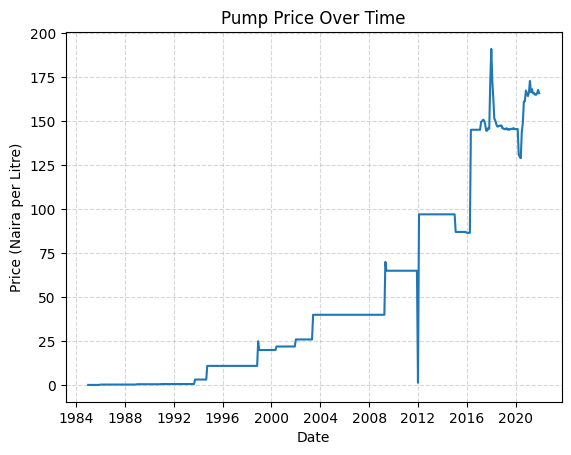

In [78]:
plt.plot(df['Date'], df['Pump_Price'])
plt.title("Pump Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (Naira per Litre)")
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()

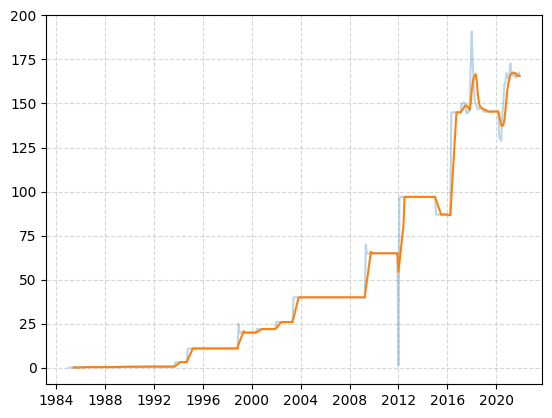

In [80]:
df['Rolling_6'] = df['Pump_Price'].rolling(window=6).mean()

plt.plot(df['Date'], df['Pump_Price'], alpha=0.3)
plt.plot(df["Date"], df["Rolling_6"])
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()

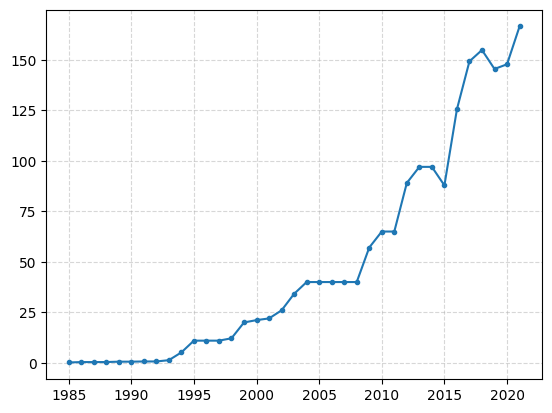

In [128]:
df["Year"] = df['Date'].dt.year.astype('float64')
yearly = df.groupby("Year")['Pump_Price'].mean()
plt.plot(yearly.index, yearly.values, marker = "o", markersize = 3)
plt.grid(True,  linestyle = "--", alpha = 0.5)
plt.show()

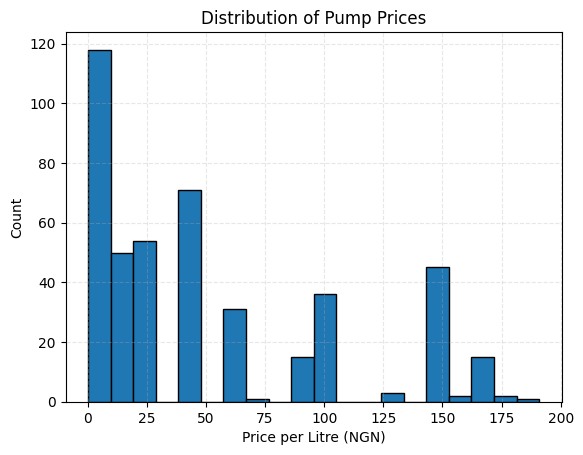

In [86]:
plt.hist(df["Pump_Price"], bins = 20, edgecolor = "black")
plt.xlabel("Price per Litre (NGN)")
plt.ylabel("Count")
plt.title("Distribution of Pump Prices")
plt.grid(True, linestyle = "--", alpha = 0.3)
plt.show()

In [87]:
df[df['Pump_Price'] > df['Pump_Price'].mean() + 2*df["Pump_Price"].std()]

,Date,Pump_Price,Rolling_6,Year
397,2017-12-01,171.79,150.090000,2017
398,2018-01-01,190.87,157.200000,2018
399,2018-02-01,172.46,161.871667,2018
400,2018-03-01,163.39,165.016667,2018
430,2020-09-01,161.06,140.476667,2020
431,2020-10-01,161.17,145.531667,2020
432,2020-11-01,167.27,151.798333,2020
433,2020-12-01,165.70,157.935000,2020
434,2021-01-01,164.09,161.345000,2021
435,2021-02-01,166.24,164.255000,2021


In [88]:
df1 = pd.read_csv("API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_115367.csv", sep="\t", skiprows=4)
df1.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025'],
      dtype='str')

In [89]:
df1 = df1[df1["Country Name"] == "Nigeria"]
df1.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
174,Nigeria,NGA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.444327,6.279147,5.265632,-2.694655,0.856793,4.103459,...,15.696813,16.502266,12.095107,11.396422,13.246023,16.952846,18.847188,24.65955,33.242097,NaN


In [90]:
df1 = df1.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])
df1.head()

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
174,Nigeria,5.444327,6.279147,5.265632,-2.694655,0.856793,4.103459,9.690346,-3.726337,-0.476059,...,15.696813,16.502266,12.095107,11.396422,13.246023,16.952846,18.847188,24.65955,33.242097,NaN


In [91]:
df1 = df1.melt(var_name="Year", value_name="Value")
df1["Year"] = pd.to_numeric(df1["Year"], errors = "coerce")
df1.head()

,Year,Value
0,NaN,Nigeria
1,1960.0,5.444327
2,1961.0,6.279147
3,1962.0,5.265632
4,1963.0,-2.694655


In [92]:
df1 = df1.iloc[1:].reset_index(drop=True)
df1.head()

,Year,Value
0,1960.0,5.444327
1,1961.0,6.279147
2,1962.0,5.265632
3,1963.0,-2.694655
4,1964.0,0.856793


In [93]:
df1 = df1.sort_values("Year").reset_index(drop=True)
df1.head()




,Year,Value
0,1960.0,5.444327
1,1961.0,6.279147
2,1962.0,5.265632
3,1963.0,-2.694655
4,1964.0,0.856793


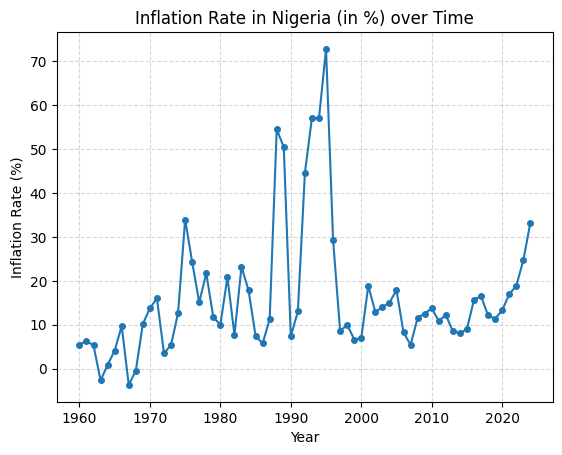

In [94]:
plt.plot(df1['Year'], df1['Value'], marker = "o", markersize = 4)
plt.title("Inflation Rate in Nigeria (in %) over Time")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()

In [97]:
df1.sort_values('Value', ascending=False).head(10)

,Year,Value
35,1995.0,72.835502
33,1993.0,57.165253
34,1994.0,57.031709
28,1988.0,54.511225
29,1989.0,50.466688
32,1992.0,44.588843
15,1975.0,33.964188
64,2024.0,33.242097
36,1996.0,29.268293
63,2023.0,24.65955


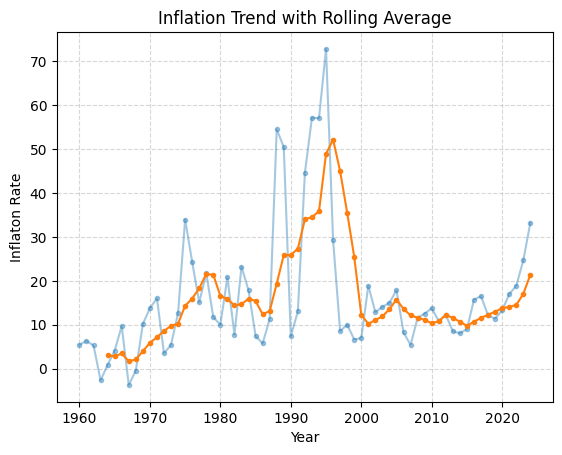

In [112]:
df1['Rolling_Avg'] = df1['Value'].rolling(window=5).mean()
plt.plot(df1["Year"], df1["Value"], alpha = 0.4, marker = "o", markersize = 3)
plt.plot( df1['Year'], df1['Rolling_Avg'], marker ="o", markersize = 3)
plt.title("Inflation Trend with Rolling Average")
plt.xlabel("Year")
plt.ylabel("Inflaton Rate")
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()


In [107]:
df1["Rolling_Avg"].head(20)

0           NaN
1           NaN
2           NaN
3           NaN
4      3.030249
5      2.762075
6      3.444315
7      1.645921
8      2.089640
9      3.949478
10     5.880202
11     7.141956
12     8.578753
13     9.754498
14    10.258180
15    14.299602
16    15.959779
17    18.285816
18    21.547132
19    21.354200
Name: Rolling_Avg, dtype: float64

In [111]:
df1["Inflation_Change"] = df1["Value"].diff()
df1.sort_values("Inflation_Change", ascending=False).head(10)

,Year,Value,Rolling_Avg,Inflation_Change
28,1988.0,54.511225,19.354915,43.220902
32,1992.0,44.588843,33.987626,31.58187
15,1975.0,33.964188,14.299602,21.289795
35,1995.0,72.835502,48.925656,15.803793
23,1983.0,23.212332,14.680979,15.514584
33,1993.0,57.165253,34.518431,12.57641
41,2001.0,18.873646,10.190313,11.940354
21,1981.0,20.812823,15.858379,10.840561
9,1969.0,10.155979,3.949478,10.632038
64,2024.0,33.242097,21.389541,8.582546


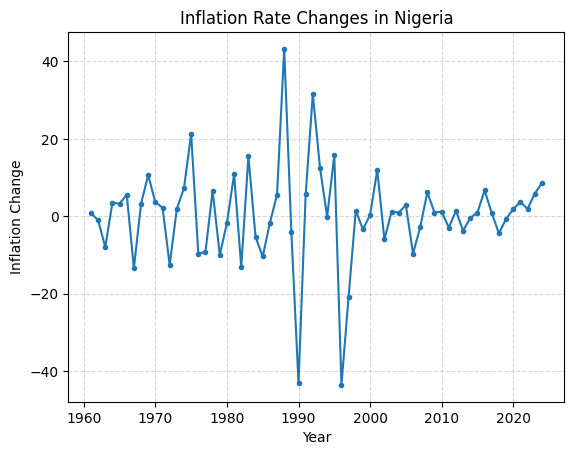

In [115]:
plt.plot(df1["Year"], df1["Inflation_Change"], marker = "o", markersize = 3)
plt.title("Inflation Rate Changes in Nigeria")
plt.xlabel("Year")
plt.ylabel("Inflation Change")
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

c:\Users\victo\Documents\dts_stuff\.prac1\Lib\site-packages\numpy\lib\_histograms_impl.py:837: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\victo\Documents\dts_stuff\.prac1\Lib\site-packages\numpy\lib\_histograms_impl.py:838: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


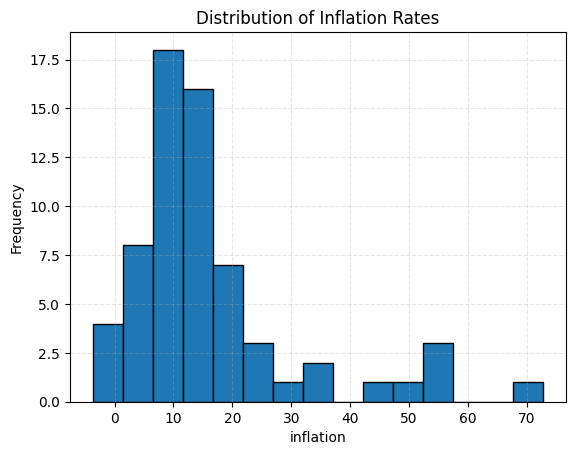

In [118]:
plt.hist(df1['Value'], bins = 15, edgecolor = 'black')
plt.title("Distribution of Inflation Rates")
plt.xlabel("inflation")
plt.ylabel("Frequency")
plt.grid(True, linestyle = "--", alpha = 0.3)
plt.show()

c:\Users\victo\Documents\dts_stuff\.prac1\Lib\site-packages\matplotlib\cbook.py:1277: RuntimeWarning: invalid value encountered in less_equal
  wiskhi = x[x <= hival]
c:\Users\victo\Documents\dts_stuff\.prac1\Lib\site-packages\matplotlib\cbook.py:1284: RuntimeWarning: invalid value encountered in greater_equal
  wisklo = x[x >= loval]
c:\Users\victo\Documents\dts_stuff\.prac1\Lib\site-packages\matplotlib\cbook.py:1292: RuntimeWarning: invalid value encountered in less
  x[x < stats['whislo']],
c:\Users\victo\Documents\dts_stuff\.prac1\Lib\site-packages\matplotlib\cbook.py:1293: RuntimeWarning: invalid value encountered in greater
  x[x > stats['whishi']],


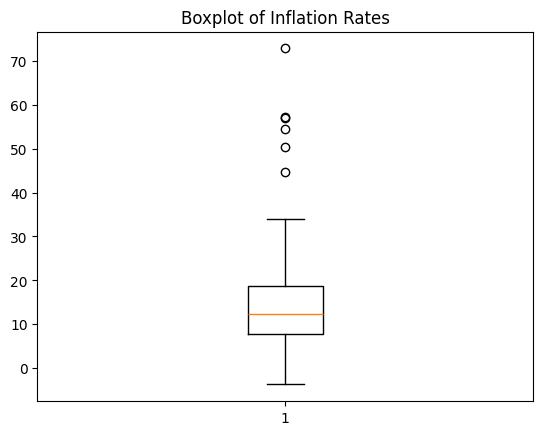

In [119]:
plt.boxplot(df1["Value"])
plt.title("Boxplot of Inflation Rates")
plt.show()

In [ ]:
df2 = pd.merge(df, df1, on = "Year")
df2.head(20)

,Date,Pump_Price,Rolling_6,Year,Value,Rolling_Avg,Inflation_Change,Cumulative
0,1985-01-01,0.2,NaN,1985.0,7.435345,15.395756,-10.385188,136.570495
1,1985-02-01,0.2,NaN,1985.0,7.435345,15.395756,-10.385188,136.570495
2,1985-03-01,0.2,NaN,1985.0,7.435345,15.395756,-10.385188,136.570495
3,1985-04-01,0.2,NaN,1985.0,7.435345,15.395756,-10.385188,136.570495
4,1985-05-01,0.2,NaN,1985.0,7.435345,15.395756,-10.385188,136.570495
5,1985-06-01,0.2,0.200000,1985.0,7.435345,15.395756,-10.385188,136.570495
6,1985-07-01,0.2,0.200000,1985.0,7.435345,15.395756,-10.385188,136.570495
7,1985-08-01,0.2,0.200000,1985.0,7.435345,15.395756,-10.385188,136.570495
8,1985-09-01,0.2,0.200000,1985.0,7.435345,15.395756,-10.385188,136.570495
9,1985-10-01,0.2,0.200000,1985.0,7.435345,15.395756,-10.385188,136.570495


In [132]:
df2[['Pump_Price', "Value"]].corr()

,Pump_Price,Value
Pump_Price,1.000000,-0.320127
Value,-0.320127,1.000000


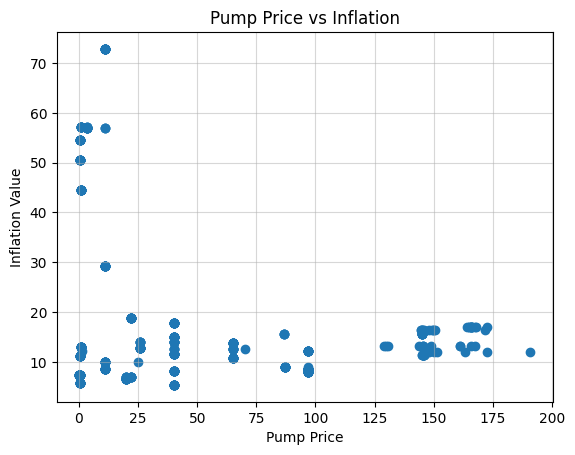

In [133]:
plt.scatter(df2['Pump_Price'], df2["Value"])
plt.title("Pump Price vs Inflation")
plt.xlabel("Pump Price")
plt.ylabel("Inflation Value")
plt.grid(True, alpha = 0.5)
plt.show()
